[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/AnirbanKopty/GWFC_DAT/blob/main/Session1/Tutorial/03_Compute_Covariance_Matrix.ipynb)

# Tutorial 3: Compute Covariance Matrix
In this notebook, we compute and visualize the time-domain covariance matrix of colored noise compared to white noise.

> ⚠️ **Warning**: 
> Uncomment and run the following cell to install necessary packages, if running in Google Collab.  
> Restart the runtime after running the cell below. To do so, go to "Runtime" and select "Restart session".

In [ ]:
# !pip install pycbc

## Covariance Matrix:

The covariance between two time samples $n_i$ and $n_j$ is defined as the expectation value:
$$C_{ij} = \mathbb{E}[(n_i - \mu_i)(n_j - \mu_j)] \tag{1} $$
where $\mu_i$ is the mean. Since gravitational wave detector noise is usually treated as zero-mean ($\mu_i = 0$), this simplifies to $C_{ij} = \mathbb{E}[n_i n_j]$. 

$$
\begin{align}
C_{ij} = \mathbb{E}[n_i n_j] = \frac {1}{M-1} \sum_{k=1}^{M} n_i^{(k)} n_j^{(k)}, \tag{2}
\end{align}
$$
where, $k$: realization index, $i,j$: random variable index



## Code:

Considering the matrix, $X_{ik} \equiv n_i^{(k)}$, the `numpy.cov` performs the following:
$$
\begin{align}
    C_{ij} = \frac 1{M-1} X_{ik} X_{kj} \tag{3}
\end{align}
$$

See that Eq. 3 matches with Eq. 2, which we desire.


In [ ]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import matplotlib.pyplot as plt

import pycbc.noise
import pycbc.psd


In [2]:
# generating several realizations of white and colored noise
sample_rate = 128
duration = 1
flow = 20
realizations = 100

delta_f = 1/duration
delta_t = 1/sample_rate
samples = int(sample_rate * duration)
flen = int(sample_rate * duration / 2) + 1

white_noise_realizations = []
for i in range(realizations):
    np.random.seed(i)
    white_noise = 1e-22 * np.random.normal(0,1, samples)   # N(0,1)
    white_noise_realizations.append(white_noise)

psd = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f=delta_f, low_freq_cutoff=flow)
colored_noise_realizations = []
for i in range(realizations):
    colored_noise = pycbc.noise.noise_from_psd(samples, delta_t=delta_t, psd=psd, seed=i)
    colored_noise_realizations.append(colored_noise)


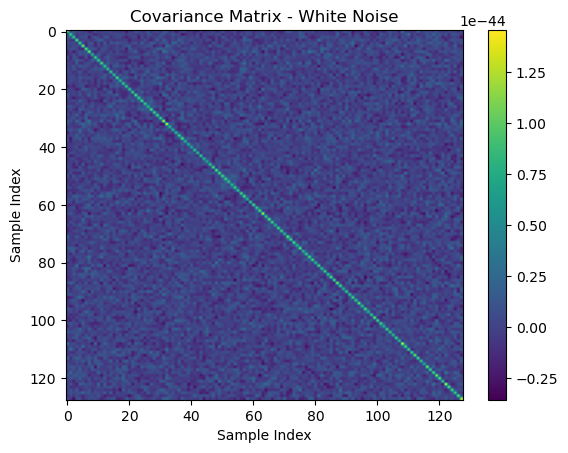

In [3]:
# covariance
white_noise_cov   = np.cov(white_noise_realizations, rowvar=False)

# plots
plt.imshow(white_noise_cov, origin='upper', aspect='auto')
plt.colorbar()
plt.title('Covariance Matrix - White Noise')
plt.xlabel('Sample Index')
plt.ylabel('Sample Index')
plt.show()


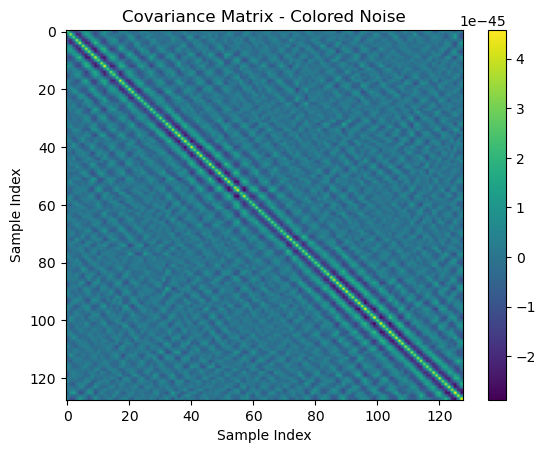

In [4]:
# covariance
colored_noise_cov   = np.cov(colored_noise_realizations, rowvar=False)

# plots
plt.imshow(colored_noise_cov, origin='upper', aspect='auto')
plt.colorbar()
plt.title('Covariance Matrix - Colored Noise')
plt.xlabel('Sample Index')
plt.ylabel('Sample Index')
plt.show()


## Toeplitz covariance matrix

For the scenario when we do not have multiple realizations of the experiment (noise), then we use stationarity principle (similar to ergodic):
We assume that the statistical properties of noise do not change over time (stationarity).  
Thus ensemble average is equivalent with averaging over a time lag. So, we define:
$$
\begin{align}
C_{ij} \equiv R[k] = \mathbb{E}[n_i n_{i+k}] = \frac {1}{N-1} \sum_{k=1}^{N-k} n_n n_{n+k}, \tag{4}
\end{align}
$$
where, $R[k]$ is autocorrelation with lag $k$.


### Code

1. `scipy.signal.correlate`: computes the correlation $R[k]$, but also with negative lags. So we discard them.

2. `scipy.linalg.toeplitz`: This converts autocorrelation values to covariance matrix form, which is called Toeplitz covariance:   
   $C_{ij} = R[|i-j|]$. (Note, $i+k=j$)


> Since the averaging is done for lag $k$ till $N-k$, thus as the lag $k$ increases, the estimate becomes "noisier". This can be resolved by performing circular autocorrelation, but that assumes periodicity of the data.  
> 
> Also, since this is generated from single noise realization, the covariance matrix structure (Toeplitz) has same elements in the diagonals.  
> $\Rightarrow$ there are diagonal lines appearing beside the principal diagonal.  


In [ ]:
from scipy.signal import correlate

sample_rate = 128
duration = 4
flow = 20

delta_f = 1/duration
delta_t = 1/sample_rate
samples = int(sample_rate * duration)
flen = int(sample_rate * duration / 2) + 1

white_noise = 1e-22 * np.random.normal(0,1, samples)   # N(0,1)
psd = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f=delta_f, low_freq_cutoff=flow)
colored_noise = pycbc.noise.noise_from_psd(samples, delta_t=delta_t, psd=psd, seed=348)


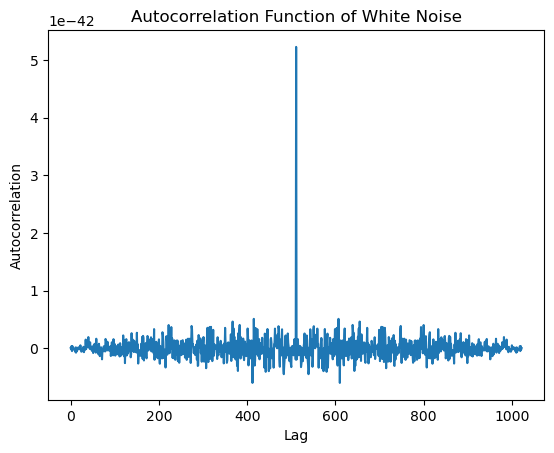

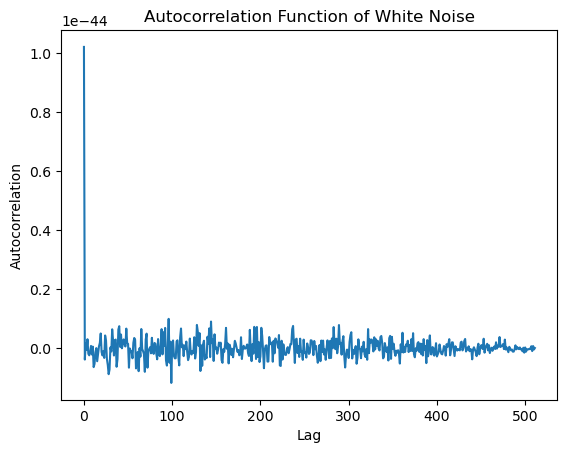

(512, 512)


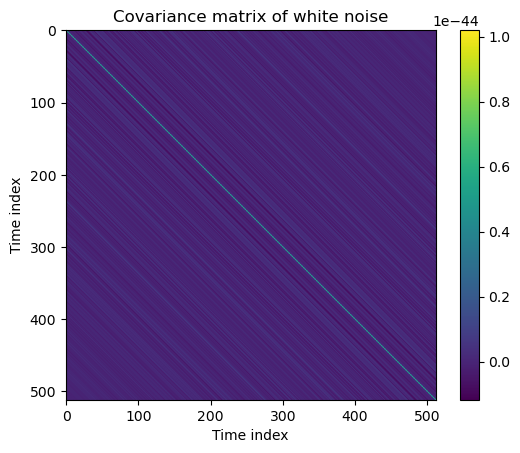

In [ ]:
from scipy.linalg import toeplitz

x = white_noise
acf = correlate(x, x, mode='full')

plt.figure()
plt.plot(acf)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function of White Noise')
plt.show()

acf = acf[len(x)-1:] / len(x)

plt.figure()
plt.plot(acf)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function of White Noise')
plt.show()

cov_white = toeplitz(acf)
print(cov_white.shape)

plt.figure()
plt.imshow(cov_white, origin='upper')
plt.colorbar()
plt.title('Covariance matrix of white noise')
plt.xlabel('Time index')
plt.ylabel('Time index')
plt.show()


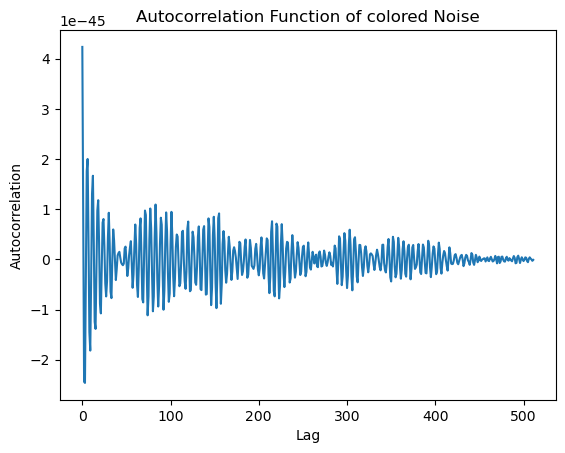

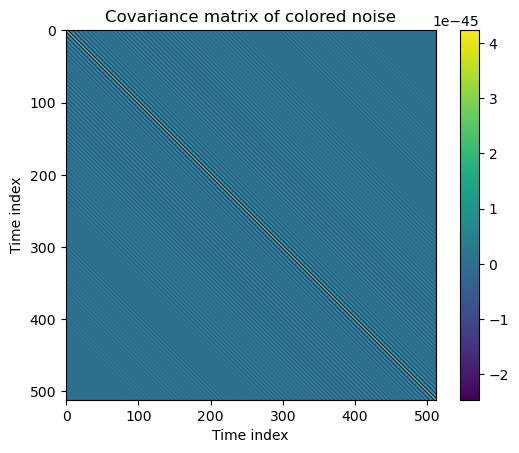

In [20]:
x = colored_noise
acf = correlate(x, x, mode='full')
acf = acf[len(x)-1:] / len(x)

plt.figure()
plt.plot(acf)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function of colored Noise')
plt.show()

cov_colored = toeplitz(acf)

plt.figure()
plt.imshow(cov_colored, origin='upper')
plt.colorbar()
plt.title('Covariance matrix of colored noise')
plt.xlabel('Time index')
plt.ylabel('Time index')
plt.show()


# In Fourier domain

DFT matrix: 
$$F_{kn} \equiv \frac 1 {\sqrt{N}} e^{-i 2 \pi k n / N} \tag{5}$$

$$\tilde A_k = F_{kn} A_n$$

Now, we want covariance matrix in Fourier domain, i.e., 
$$
\begin{align}
\tilde C_{kl} &= \mathbb{E}[\tilde n_k \tilde n_l^\dagger] 
= \mathbb{E}[F_{ki}n_i (F_{lj}n_j)^\dagger] 
= F_{ki} \mathbb{E}[n_i n_j^\dagger] F_{jl}^\dagger \tag{6} \\
\Rightarrow \tilde C_{kl} &= F_{ki} C_{ij} F_{jl}^\dagger \tag{7}
\end{align}
$$


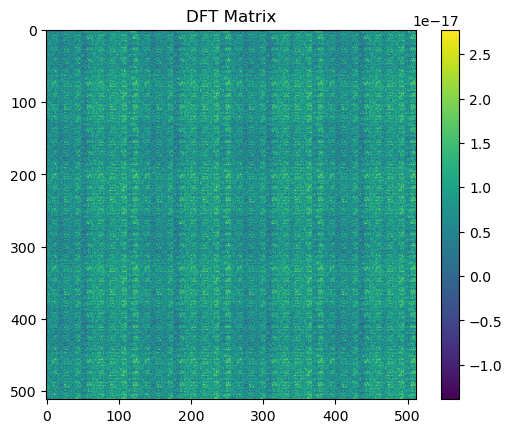

In [21]:
# construct the DFT matrix
F = np.fft.fft(np.eye(samples)) / np.sqrt(samples)  # FFT of identity matrix gives DFT matrix
Fplot = np.abs(F)

plt.imshow(Fplot - Fplot.mean(), origin='upper')
plt.colorbar()
plt.title('DFT Matrix')
plt.show()


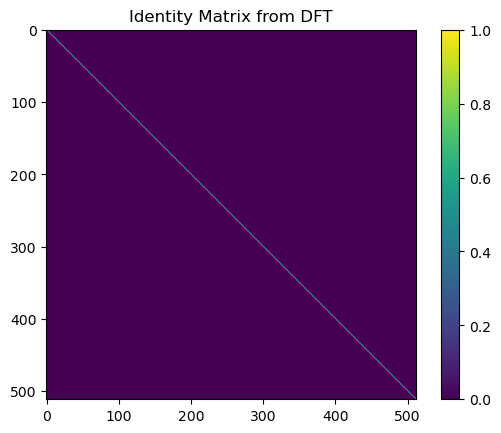

In [22]:
# checking the unitary property of the DFT matrix
I = F.conj().T @ F
plt.imshow(np.abs(I), origin='upper')
plt.colorbar()
plt.title('Identity Matrix from DFT')
plt.show()


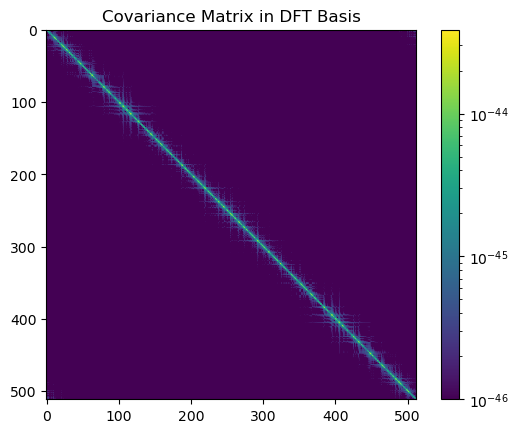

In [ ]:
# computing the covariance matrix of white noise in Fourier domain
import matplotlib.colors as mcolors

norm = mcolors.LogNorm(vmin=1e-46)

cov_white_tilde = F @ cov_white @ F.conj().T
plt.imshow(np.abs(cov_white_tilde), norm=norm, origin='upper')
plt.colorbar()
plt.title('Covariance Matrix in DFT Basis')
plt.show()


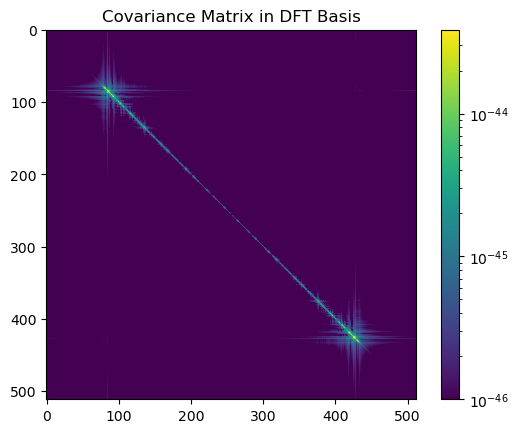

In [24]:
# same for the colored noise
cov_colored_tilde = F @ cov_colored @ F.conj().T
plt.imshow(np.abs(cov_colored_tilde), norm=norm, origin='upper')
plt.colorbar()
plt.title('Covariance Matrix in DFT Basis')
plt.show()


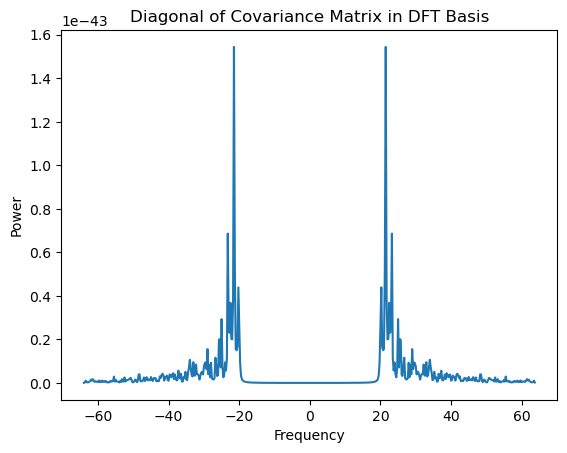

In [25]:
psd = np.abs(np.diag(cov_colored_tilde))
freqs = np.fft.fftfreq(samples, d=delta_t)

idx = np.argsort(freqs)
freqs = freqs[idx]
psd = psd[idx]

plt.plot(freqs, psd)
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('Diagonal of Covariance Matrix in DFT Basis')
plt.show()


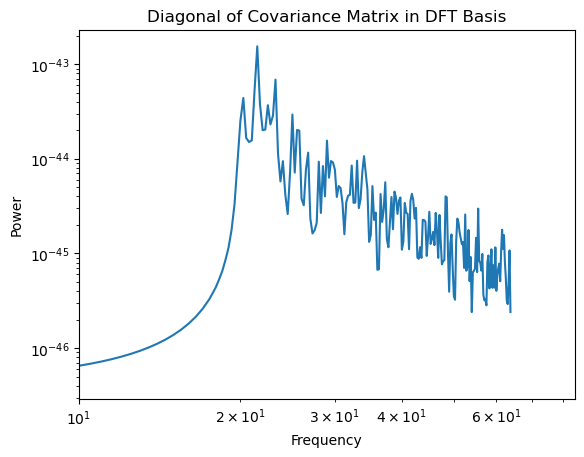

In [26]:
mask = freqs > 0

plt.loglog(freqs[mask], psd[mask])
plt.xlim(left=10)
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('Diagonal of Covariance Matrix in DFT Basis')
plt.show()


## Questions:

1. Why do you see a falloff at 20 Hz?
2. Why do you see till 64 Hz?
3. Use higher sample rate to see how this PSD changes.


## Adding non-gausianity and check covariance

We add a sine-gaussian glitch:
$$g(t) = A \sin (2 \pi f_0 (t-t_0)) \exp \left[ - \frac{(t-t_0)^2}{2\sigma^2} \right]$$

In [14]:
def compute_fd_covariance_matrix(x):
    acf = correlate(x, x, mode='full')
    acf = acf[len(x)-1:] / len(x)
    C = toeplitz(acf)

    C_tilde = F @ C @ F.conj().T
    return C_tilde

def sine_gaussian(t, A, f0, t0, sigma):
    return A * np.sin(2*np.pi*f0*(t-t0)) \
    * np.exp(-0.5 * ((t - t0) / sigma)**2)

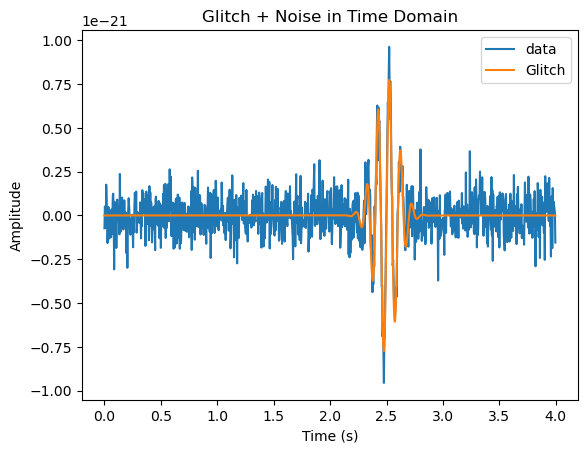

In [15]:
A = 8e-22
f0 = 10
t0 = 2.5
sigma = 0.1

times = np.arange(samples) / sample_rate
glitch = sine_gaussian(times, A, f0, t0, sigma)

data = white_noise + glitch

plt.plot(times, data, label='data', color='C0')
plt.plot(times, glitch, label='Glitch', color='C1')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Glitch + Noise in Time Domain')
plt.legend()
plt.show()


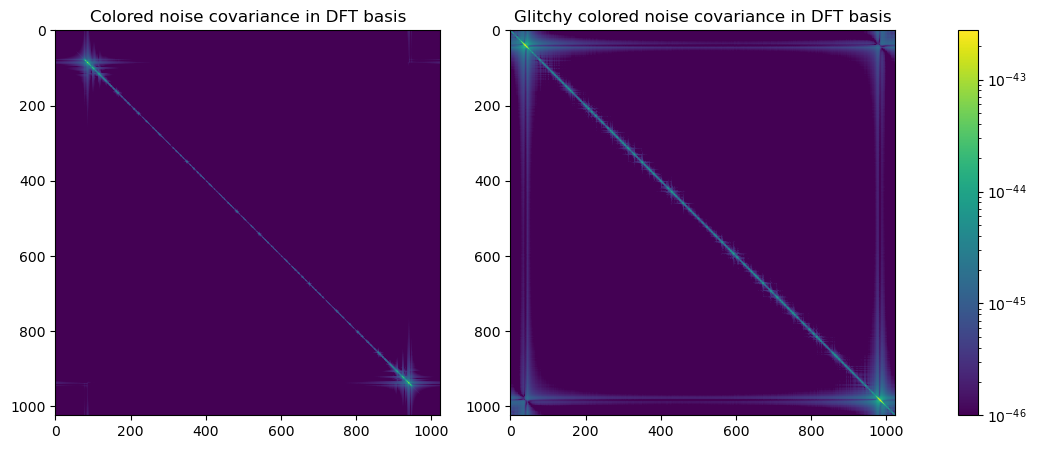

In [17]:
cov_colored_tilde = compute_fd_covariance_matrix(colored_noise)
cov_data_tilde = compute_fd_covariance_matrix(data)

fig, ax = plt.subplots(1, 3, figsize=(12, 5), width_ratios=[1,1,0.05])
norm = mcolors.LogNorm(vmin=1e-46)
ax[0].imshow(np.abs(cov_colored_tilde), norm=norm, origin='upper')
fig = ax[1].imshow(np.abs(cov_data_tilde), norm=norm, origin='upper')
plt.colorbar(fig, cax=ax[2])
ax[0].set_title('Colored noise covariance in DFT basis')
ax[1].set_title('Glitchy colored noise covariance in DFT basis')
plt.show()


## Questions

4. Try adding different non-gaussian features in the noise and see how the covariance matrix changes.